# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

**Method: Clustering**

The method is clustering because we have no ground truth, and i am dealing with unlabelled data. and see if the groups emerges from the features selected. we don't know what each group is yet.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [122]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

In [123]:
from huggingface_hub import HfApi
api = HfApi()
files = api.list_repo_files("FlyRank/internship-warehouse", repo_type="dataset")

r_files = [ f for f in files if "fact_content_daily_performance" in f]
for r in r_files:
  print(r)

fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2026-03/data_0.parquet
fact_content_daily_performance/month=2026-04/data_0.parquet
fact_content_daily_performance/month=202

In [124]:
from datasets import load_dataset
import pandas as pd

cols_needed = [ 'content_hash_id', 'report_date', 'gsc_impressions', 'gsc_clicks',  'gsc_avg_position']

ds_train = load_dataset("FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-03/data_0.parquet",
    split="train", token=hf_token)
df_train = ds_train.select_columns(cols_needed).to_pandas()
del ds_train

ds_test_raw = load_dataset("FlyRank/internship-warehouse",
    data_files="fact_content_daily_performance/month=2026-06/data_0.parquet",
    split="train", token=hf_token)
ds_test = ds_test_raw.shuffle(seed=42).select(range(100_000))
df_test = ds_test.select_columns(cols_needed).to_pandas()
del ds_test_raw, ds_test

cols_needed = [ 'content_hash_id', 'word_count', 'is_published']
ds_content = load_dataset("FlyRank/internship-warehouse",
    data_files="dim_content.parquet", split="train", token=hf_token)
df_content = ds_content.select_columns(cols_needed).to_pandas()
del ds_content

df_train = df_train.merge(df_content, on="content_hash_id", how="left", validate="m:1")
df_test = df_test.merge(df_content, on="content_hash_id", how="left", validate="m:1")




In [125]:
print(df_train.shape)
print(df_test.shape)

(9841378, 7)
(100000, 7)


In [126]:
df_train.describe()

,gsc_impressions,gsc_clicks,gsc_avg_position,word_count
count,9.841378e+06,9.841378e+06,3.611061e+06,6.518014e+06
mean,2.851812e+01,8.350782e-02,1.582665e+01,2.373459e+03
std,1.559266e+02,7.814341e-01,1.985603e+01,1.244869e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,3.742120e+00,1.357000e+03
50%,0.000000e+00,0.000000e+00,7.500000e+00,2.469000e+03
75%,6.000000e+00,0.000000e+00,2.020000e+01,3.033000e+03
max,4.008400e+04,2.740000e+02,4.980000e+02,2.934100e+04


In [127]:
df_test.describe()

,gsc_impressions,gsc_clicks,gsc_avg_position,word_count
count,100000.000000,100000.000000,33420.000000,72566.000000
mean,19.486220,0.077050,21.208941,2499.521663
std,160.364834,0.886466,24.271492,1129.388272
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,5.600000,1530.000000
50%,0.000000,0.000000,10.000000,2620.000000
75%,3.000000,0.000000,28.836039,3047.750000
max,20104.000000,147.000000,479.000000,29341.000000


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [128]:


df_train["CTR"] = (df_train["gsc_clicks"] / df_train["gsc_impressions"]) * 100
df_test["CTR"] = (df_test["gsc_clicks"] / df_test["gsc_impressions"]) * 100

df_train.sort_values(by=['report_date', 'content_hash_id'], ascending=True, inplace=True)

df_train["trend_direction"] = df_train.groupby("content_hash_id")["gsc_avg_position"].diff().fillna(0)
df_test["trend_direction"] = df_test.groupby("content_hash_id")["gsc_avg_position"].diff().fillna(0)

In [129]:
import numpy as np

for col in ['CTR', 'word_count', 'gsc_impressions', 'gsc_clicks']:
    train_median = df_train[col].median()
    df_train[col] = df_train[col].fillna(train_median)
    df_test[col] = df_test[col].fillna(train_median)

for col in ['gsc_impressions', 'gsc_clicks', 'word_count', 'CTR']:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])


df_train['trend_direction'] = np.sign(df_train['trend_direction']) * np.log1p(np.abs(df_train['trend_direction']))
df_test['trend_direction'] = np.sign(df_test['trend_direction']) * np.log1p(np.abs(df_test['trend_direction']))


feature_cols = ["gsc_impressions", "gsc_clicks", "word_count", "CTR", "trend_direction"]


In [130]:
# 1. Unique value counts -- likely explains the striping
for col in feature_cols:
    print(col, "-> unique values:", df_train[col].nunique())

# 2. Distribution shape after transforms -- look for a long tail still remaining
print(df_train[feature_cols].describe(percentiles=[.5, .9, .95, .99, .999]))

gsc_impressions -> unique values: 4854
gsc_clicks -> unique values: 140
word_count -> unique values: 6820
CTR -> unique values: 15529
trend_direction -> unique values: 1531834
       gsc_impressions    gsc_clicks    word_count           CTR  \
count     9.841378e+06  9.841378e+06  9.841378e+06  9.841378e+06   
mean      1.088434e+00  4.027734e-02  7.691194e+00  3.591842e-02   
std       1.732799e+00  2.108273e-01  4.580017e-01  2.230226e-01   
min       0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%       0.000000e+00  0.000000e+00  7.811973e+00  0.000000e+00   
90%       4.007333e+00  0.000000e+00  8.162801e+00  0.000000e+00   
95%       4.912655e+00  0.000000e+00  8.331345e+00  0.000000e+00   
99%       6.234411e+00  1.098612e+00  8.690642e+00  1.112126e+00   
99.9%     7.491645e+00  2.197225e+00  8.912473e+00  2.871680e+00   
max       1.059876e+01  5.616771e+00  1.028678e+01  4.615121e+00   

       trend_direction  
count     9.841378e+06  
mean      3.551375e-03  


In [131]:
q1 = df_train['CTR'].quantile(0.25)
q3 = df_train['CTR'].quantile(0.75)
print(f"Q1: {q1}, Q3: {q3}, IQR: {q3 - q1}")

Q1: 0.0, Q3: 0.0, IQR: 0.0


In [132]:
df_train = df_train[(df_train['is_published'] == True) & (df_train['gsc_avg_position'] <= 100)]
df_test = df_test[(df_test['is_published'] == True) & (df_test['gsc_avg_position'] <= 100)]

                  gsc_avg_position  trend_direction  gsc_impressions  \
gsc_avg_position          1.000000         0.269355        -0.193352   
trend_direction           0.269355         1.000000         0.005163   
gsc_impressions          -0.193352         0.005163         1.000000   
gsc_clicks               -0.123783        -0.006687         0.469527   
word_count                0.012389        -0.001617         0.169190   
CTR                      -0.100454        -0.010005         0.187579   

                  gsc_clicks  word_count       CTR  
gsc_avg_position   -0.123783    0.012389 -0.100454  
trend_direction    -0.006687   -0.001617 -0.010005  
gsc_impressions     0.469527    0.169190  0.187579  
gsc_clicks          1.000000    0.031731  0.656092  
word_count          0.031731    1.000000  0.001170  
CTR                 0.656092    0.001170  1.000000  


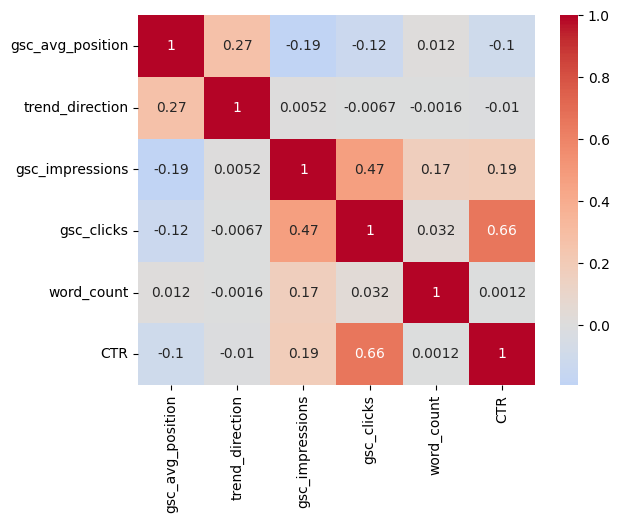

In [133]:
corr = df_train[["gsc_avg_position", "trend_direction", "gsc_impressions",
                       "gsc_clicks", "word_count", "CTR"]].corr()
print(corr)

# visually, a heatmap makes it easier to eyeball at a glance:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

In [134]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

feature_cols = ["gsc_impressions", "word_count", "CTR", "trend_direction", "gsc_avg_position"]

df_train_k = df_train[feature_cols]
df_test_k = df_test[feature_cols]

scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_train_scaled = scaler.fit_transform(df_train_k).astype(np.float32)
X_test_scaled = scaler.transform(df_test_k).astype(np.float32)

rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train_scaled), size=min(1_000_000, len(X_train_scaled)), replace=False)
X_sample = X_train_scaled[sample_idx]

results = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42, max_iter=300)
    labels = km.fit_predict(X_sample)
    labels_test = km.predict(X_test_scaled)

    score = silhouette_score(X_sample, labels, sample_size=5_000, random_state=42)
    score_test = silhouette_score(X_test_scaled, labels_test, sample_size=5_000, random_state=42)

    results.append({"k": k, "silhouette_train": score, "silhouette_test": score_test, "inertia": km.inertia_})
    print(f"k={k} | silhouette train: {score:.4f} | silhouette test: {score_test:.4f} | inertia: {km.inertia_:,.0f}")

results_df = pd.DataFrame(results)



k=2 | silhouette train: 0.5848 | silhouette test: 0.6437 | inertia: 7,107,725
k=3 | silhouette train: 0.5799 | silhouette test: 0.6487 | inertia: 4,466,332
k=4 | silhouette train: 0.5867 | silhouette test: 0.6537 | inertia: 3,472,215
k=5 | silhouette train: 0.3242 | silhouette test: 0.3413 | inertia: 2,840,729
k=6 | silhouette train: 0.3137 | silhouette test: 0.3581 | inertia: 2,482,848
k=7 | silhouette train: 0.3197 | silhouette test: 0.3622 | inertia: 2,242,190
k=8 | silhouette train: 0.3309 | silhouette test: 0.3630 | inertia: 2,023,026
k=9 | silhouette train: 0.3257 | silhouette test: 0.3341 | inertia: 1,880,967


Explained variance ratio: [0.44886935 0.2392649  0.16395499]
Total variance explained: 85.21%


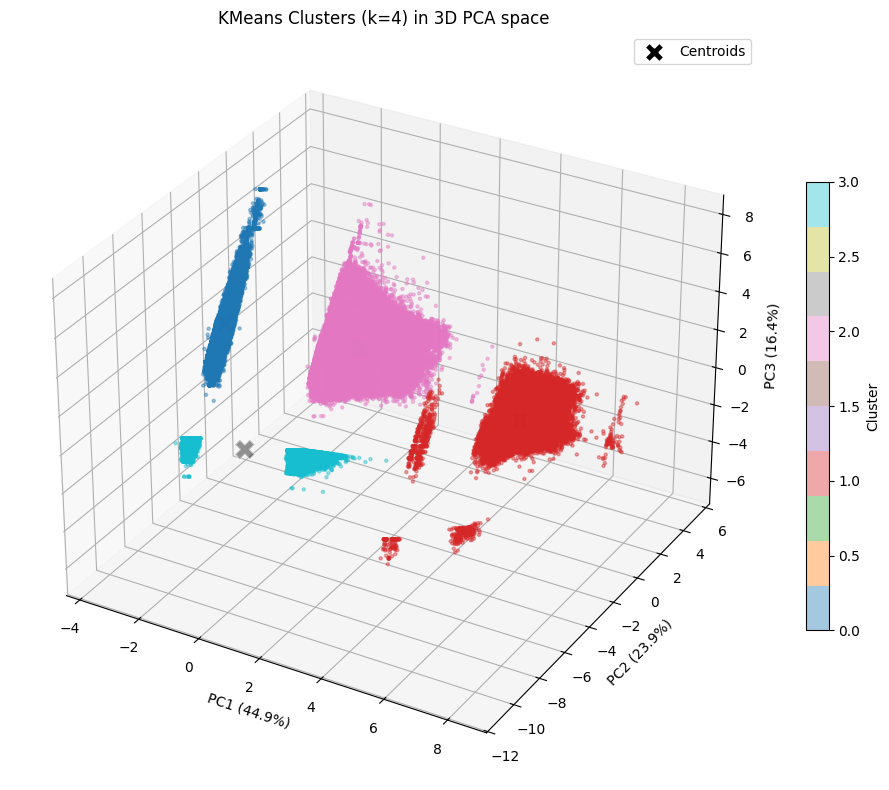

In [137]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

best_k = 4
km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=20, random_state=42, max_iter=300)
train_labels = km_final.fit_predict(X_sample)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_sample)
centroids_pca = pca.transform(km_final.cluster_centers_)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=train_labels, cmap='tab10', s=5, alpha=0.4
)

ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1], centroids_pca[:, 2],
    c='black', marker='X', s=200, edgecolor='white', linewidth=1.5, label='Centroids'
)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_zlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
ax.set_title(f"KMeans Clusters (k={best_k}) in 3D PCA space")
ax.legend()

plt.colorbar(scatter, ax=ax, label='Cluster', shrink=0.6)
plt.tight_layout()
plt.show()

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.